<h3><b>1. Load the Cleaned Dataset <b><h3>

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data" / "processed" / "concrete_data_cleaned.csv").exists()
)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "concrete_data_cleaned.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "processed"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FEATURES_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (911, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


<h3><b>2. Separate Features and Target <b><h3>

In [24]:
target_column = "compressive_strength"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

Feature shape: (911, 8)
Target shape: (911,)

Input features:
['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']


<h3><b>3. Feature Selection Using Variance Threshold</b></h3>


In [25]:
variance_selector = VarianceThreshold(threshold=0.01)
X_selected_array = variance_selector.fit_transform(X)


selected_features = X.columns[
variance_selector.get_support()
].tolist()

removed_features = X.columns[
    ~variance_selector.get_support()
].tolist()



X_selected = pd.DataFrame(
    X_selected_array,
    columns=selected_features,
    index=X.index,
)



feature_variances = pd.DataFrame({
    "Feature": X.columns,
    "Variance": variance_selector.variances_,
    "Selected": variance_selector.get_support(),
})

display(feature_variances)

print("Selected features:", selected_features)

print(
    "Removed features:",
    removed_features if removed_features else "None"
)

print("Features before selection:", X.shape[1])
print("Features after selection:", X_selected.shape[1])
print("Shape after feature selection:", X_selected.shape)

,Feature,Variance,Selected
0,cement,10272.391249,True
1,blast_furnace_slag,7412.763433,True
2,fly_ash,4160.088733,True
3,water,345.068056,True
4,superplasticizer,27.379331,True
5,coarse_aggregate,6011.520101,True
6,fine_aggregate,5669.353585,True
7,age,806.840788,True


Selected features: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']
Removed features: None
Features before selection: 8
Features after selection: 8
Shape after feature selection: (911, 8)


<h3><b>4. Standardize the Selected Features</b></h3>

In [31]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_selected)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_selected.columns,
    index=X_selected.index,
)


print("Mean of scaled features:")
print(X_scaled.mean().round(4))

print("\nStandard deviation of scaled features:")
print(X_scaled.std(ddof=0).round(4))

display(X_scaled.head())

Mean of scaled features:
cement                0.0
blast_furnace_slag   -0.0
fly_ash               0.0
water                 0.0
superplasticizer     -0.0
coarse_aggregate      0.0
fine_aggregate        0.0
age                  -0.0
dtype: float64

Standard deviation of scaled features:
cement                1.0
blast_furnace_slag    1.0
fly_ash               1.0
water                 1.0
superplasticizer      1.0
coarse_aggregate      1.0
fine_aggregate        1.0
age                   1.0
dtype: float64


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
0,2.546108,-0.828631,-0.939741,-1.064864,-0.694339,0.948905,-1.384896,-0.142238
1,-0.203407,0.346693,-0.939741,1.919358,-1.178736,-0.730963,-1.519488,2.099639
2,1.077286,0.241817,-0.939741,2.356192,-1.178736,-0.582995,-2.457401,-0.109066
3,0.033160,0.531803,-0.939741,2.659765,-1.178736,-0.480166,-1.371769,-0.044334
4,1.781839,-0.828631,-0.939741,2.017147,-1.178736,-0.697839,-2.457401,-0.181361


<h3><b>5. Save the Scaled Feature Dataset</b></h3>

In [36]:
scaled_dataset = X_scaled.copy()

# Add target variable back to the dataset
scaled_dataset[target_column] = y.to_numpy()

SCALED_DATA_PATH = FEATURES_PATH / "concrete_features_scaled.csv"

scaled_dataset.to_csv(
    SCALED_DATA_PATH,
    index=False
)

print(f"Saved scaled dataset to: {SCALED_DATA_PATH}")
print("Scaled dataset shape:", scaled_dataset.shape)

display(scaled_dataset.head())

Saved scaled dataset to: c:\Users\asus\Desktop\AIML\Concrete-Compressive-Strength-Predictor\Concrete-Compressive-Strength-Predictor\data\processed\concrete_features_scaled.csv
Scaled dataset shape: (911, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,2.546108,-0.828631,-0.939741,-1.064864,-0.694339,0.948905,-1.384896,-0.142238,61.89
1,-0.203407,0.346693,-0.939741,1.919358,-1.178736,-0.730963,-1.519488,2.099639,47.03
2,1.077286,0.241817,-0.939741,2.356192,-1.178736,-0.582995,-2.457401,-0.109066,36.45
3,0.033160,0.531803,-0.939741,2.659765,-1.178736,-0.480166,-1.371769,-0.044334,45.85
4,1.781839,-0.828631,-0.939741,2.017147,-1.178736,-0.697839,-2.457401,-0.181361,39.29


<h3><b>6. Dimensionality Reduction Using PCA</b></h3>

<h5><b>Principal Component Analysis (PCA) reduces the dimensionality of the selected features by transforming them into a smaller set of uncorrelated principal components. The components are retained until at least 95% of the total variance in the data is preserved.</b></h5>


In [40]:
#keep at least 95% of the important information in the data
pca = PCA(n_components=0.95)


# Apply PCA to scaled features
X_pca_array = pca.fit_transform(X_scaled)


# Create names such as PC1, PC2, PC3...
pca_columns = [
    f"PC{i + 1}"
    for i in range(X_pca_array.shape[1])
]


# Convert PCA output to DataFrame
X_pca = pd.DataFrame(
    X_pca_array,
    columns=pca_columns,
    index=X_scaled.index,
)


print("Features before PCA:", X_scaled.shape[1])
print("Principal components retained:", X_pca.shape[1])

display(X_pca.head())

Features before PCA: 8
Principal components retained: 6


,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.941906,-2.486140,1.901685,-0.989733,0.018550,-0.512494
1,-2.274087,1.259564,0.206556,-1.229815,2.045543,0.783732
2,-3.079089,0.425612,1.518911,-0.851404,0.116465,1.595310
3,-2.911998,0.988176,0.268183,-0.266618,0.152450,1.321979
4,-2.768404,-0.605953,2.044112,-0.600911,0.452171,1.887523


<h3><b>7. Analyze Explained Variance of Principal Components</b></h3>

In [43]:
explained_variance = pd.DataFrame({
    "Principal Component": pca_columns,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance":
        np.cumsum(pca.explained_variance_ratio_),
})


display(explained_variance)


print(
    "\nTotal explained variance retained:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.268528,0.268528
1,PC2,0.176264,0.444792
2,PC3,0.150021,0.594813
3,PC4,0.136383,0.731196
4,PC5,0.128761,0.859957
5,PC6,0.108552,0.968509



Total explained variance retained: 0.9685


<h3><b>8. Visualize Explained Variance</b></h3>

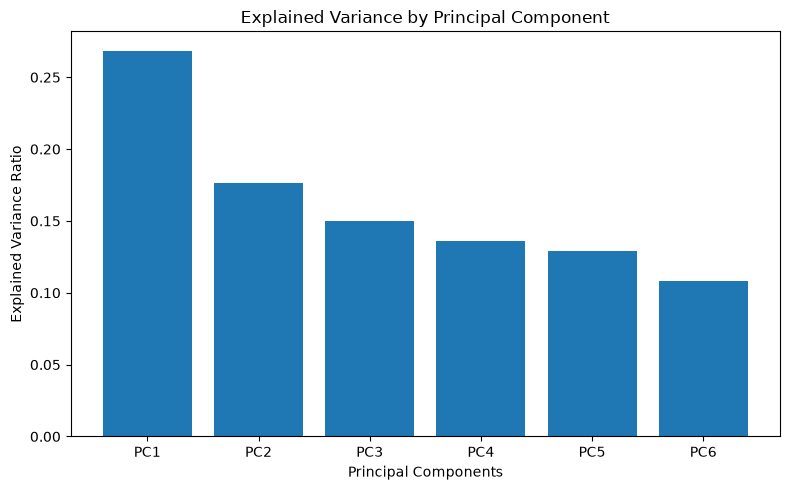

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    pca_columns,
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "pca_explained_variance.png",
    dpi=300
)

plt.show()
plt.close()

<h3><b>9. PCA Feature Loadings and Contributions</b></h3>

In [46]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=pca_columns,
)


print("Feature loadings for all Principal Components:")

display(pca_loadings)

Feature loadings for all Principal Components:


,PC1,PC2,PC3,PC4,PC5,PC6
cement,-0.174706,-0.437454,0.716008,0.139404,0.092410,-0.038566
blast_furnace_slag,-0.234038,0.649536,0.053865,-0.109092,-0.287979,-0.432546
fly_ash,0.531360,0.107164,-0.098126,-0.124323,-0.096328,0.592972
water,-0.527125,0.224699,-0.082389,0.145385,0.034371,0.527402
superplasticizer,0.548095,0.181929,0.358189,-0.029519,-0.202799,-0.170013
coarse_aggregate,-0.089379,-0.510566,-0.408081,-0.486727,-0.311885,-0.208727
fine_aggregate,0.199535,-0.099181,-0.413171,0.731150,0.167880,-0.291787
age,0.079307,0.145434,-0.049745,-0.399648,0.855269,-0.155038


<h3><b>10. Display Feature Contributions for Each Principal Component</b></h3>

In [47]:
for pc in pca_loadings.columns:

    pc_contributions = pd.DataFrame({
        "Loading": pca_loadings[pc],
        "Absolute Contribution": pca_loadings[pc].abs(),
    })

    # Sort by contribution strength
    pc_contributions = pc_contributions.sort_values(
        by="Absolute Contribution",
        ascending=False,
    )

    print(f"\nFeatures contributing to {pc}:")

    display(pc_contributions)


Features contributing to PC1:


,Loading,Absolute Contribution
superplasticizer,0.548095,0.548095
fly_ash,0.531360,0.531360
water,-0.527125,0.527125
blast_furnace_slag,-0.234038,0.234038
fine_aggregate,0.199535,0.199535
cement,-0.174706,0.174706
coarse_aggregate,-0.089379,0.089379
age,0.079307,0.079307



Features contributing to PC2:


,Loading,Absolute Contribution
blast_furnace_slag,0.649536,0.649536
coarse_aggregate,-0.510566,0.510566
cement,-0.437454,0.437454
water,0.224699,0.224699
superplasticizer,0.181929,0.181929
age,0.145434,0.145434
fly_ash,0.107164,0.107164
fine_aggregate,-0.099181,0.099181



Features contributing to PC3:


...

,Loading,Absolute Contribution
fine_aggregate,0.731150,0.731150
coarse_aggregate,-0.486727,0.486727
age,-0.399648,0.399648
water,0.145385,0.145385
cement,0.139404,0.139404
fly_ash,-0.124323,0.124323
blast_furnace_slag,-0.109092,0.109092
superplasticizer,-0.029519,0.029519



Features contributing to PC5:


,Loading,Absolute Contribution
age,0.855269,0.855269
coarse_aggregate,-0.311885,0.311885
blast_furnace_slag,-0.287979,0.287979
superplasticizer,-0.202799,0.202799
fine_aggregate,0.167880,0.167880
fly_ash,-0.096328,0.096328
cement,0.092410,0.092410
water,0.034371,0.034371



Features contributing to PC6:


,Loading,Absolute Contribution
fly_ash,0.592972,0.592972
water,0.527402,0.527402
blast_furnace_slag,-0.432546,0.432546
fine_aggregate,-0.291787,0.291787
coarse_aggregate,-0.208727,0.208727
superplasticizer,-0.170013,0.170013
age,-0.155038,0.155038
cement,-0.038566,0.038566


<h3><b>11. Final PCA Dataset</b></h3>

In [ ]:
pca_dataset = X_pca.copy()

pca_dataset[target_column] = y.to_numpy()


PCA_DATA_PATH = FEATURES_PATH / "concrete_data_pca.csv"

pca_dataset.to_csv(
    PCA_DATA_PATH,
    index=False
)


display(pca_dataset.head())

print("Final PCA dataset shape:", pca_dataset.shape)

print(f"Saved PCA dataset to: {PCA_DATA_PATH}")

,PC1,PC2,PC3,PC4,PC5,PC6,compressive_strength
0,-0.941906,-2.486140,1.901685,-0.989733,0.018550,-0.512494,61.89
1,-2.274087,1.259564,0.206556,-1.229815,2.045543,0.783732,47.03
2,-3.079089,0.425612,1.518911,-0.851404,0.116465,1.595310,36.45
3,-2.911998,0.988176,0.268183,-0.266618,0.152450,1.321979,45.85
4,-2.768404,-0.605953,2.044112,-0.600911,0.452171,1.887523,39.29


Final PCA dataset shape: (911, 7)
Saved PCA dataset to: c:\Users\asus\Desktop\AIML\Concrete-Compressive-Strength-Predictor\Concrete-Compressive-Strength-Predictor\data\processed\concrete_data_pca.csv


: 